In [1]:
# USE DATA FROM POWERMODELS.BUILD_REF AS A DICTIONARY
# MATCH `def generateindices(d):`FROM JULIA AND PYTHON

In [1]:
# # Change jupyter notebook theme
# from jupyterthemes import get_themes
# import jupyterthemes as jt
# from jupyterthemes.stylefx import set_nb_theme
# set_nb_theme('onedork')

In [28]:
# import necessary packages
import numpy as np
import pandas as pd
# import pandapower as pp
# import pandapower.control as control
# import pandapower.networks as nw
# import pandapower.timeseries as timeseries
# from pandapower.timeseries.data_sources.frame_data import DFData
# import pandapower.plotting as plt
import matplotlib.pyplot as mplt 
from scipy.optimize import minimize
import pyomo.environ as pyo
import json

In [30]:
# DON'T DELETE. Define required classes
class Bus:
    def __init__(self, pd, gs, gens):
        self.pd = pd  # Float64
        self.gs = gs  # Float64
        self.gens = gens  # List of Int
        
class Gen:
    def __init__(self, bus, pmin, pmax, pstart, cost):
        self.bus = bus  # Int
        self.pmin = pmin  # Float64
        self.pmax = pmax  # Float64
        self.pstart = pstart  # Float64
        self.cost = cost  # List of Float64

class Line:
    def __init__(self, rate, frombus, tobus, beta):
        self.rate = rate  # Float64
        self.frombus = frombus  # Int
        self.tobus = tobus  # Int
        self.beta = beta  # Float64
        
class NetworkReference:
    def __init__(self, ref, nbus, ngen, nline, r, bus, gen, line, originalindices, B, pi, stdw, line_prob=0.9, bus_prob=0.9):
        self.ref = ref  # Dictionary of ref data
        self.nbus = nbus  # Number of buses
        self.ngen = ngen  # Number of generators
        self.nline = nline  # Number of lines
        self.r = r  # Reference bus index
        self.bus = bus  # List of Bus objects
        self.gen = gen  # List of Gen objects
        self.line = line  # List of Line objects
        self.originalindices = originalindices  # Original indices (bus/gen/line)
        self.B = B  # Admittance matrix
        self.pi = pi  # Inverse reduced admittance matrix
        self.stdw = stdw  # List of standard deviations
        self.line_prob = line_prob  # Line probability
        self.bus_prob = bus_prob  # Bus probability

In [31]:
# DON'T DELETE. Define required functions
def getstart(dct, item_key, value_key, default=0.0):
    return dct.get(item_key, {}).get(value_key, default)
def admittancematrix(ref, bus_index):
    nbus = len(ref['bus'])
    B = np.zeros((nbus, nbus))  # Create a square matrix of zeros with dimensions (nbus, nbus)
    
    for i, branch in ref['branch'].items():  # Iterate over ref['branch'] items
        f_bus = bus_index[ref['bus'][str(branch["f_bus"])]["index"]]-1
        t_bus = bus_index[ref['bus'][str(branch["t_bus"])]["index"]]-1
#         f_bus = bus_index[ref['bus'][branch["f_bus"]]["index"]]-1
#         t_bus = bus_index[ref['bus'][branch["t_bus"]]["index"]]-1
        
        # Update the elements of matrix B based on the formulas provided
        B[f_bus, t_bus] += (-branch["br_x"] / (branch["br_x"] ** 2 + branch["br_r"] ** 2))
        B[t_bus, f_bus] += (-branch["br_x"] / (branch["br_x"] ** 2 + branch["br_r"] ** 2))
        B[f_bus, f_bus] += (branch["br_x"] / (branch["br_x"] ** 2 + branch["br_r"] ** 2))
        B[t_bus, t_bus] += (branch["br_x"] / (branch["br_x"] ** 2 + branch["br_r"] ** 2))    
    return B

def NetworkReference_func(ref, bus_prob = 0.9, line_prob = 0.9, sigma_scaling = 0.05):
    def generateindices(d):
        originalindices = sorted(int(i) for i in d)
        reverseindices = {key: i for i, key in enumerate(originalindices, 1)}
        return len(originalindices), originalindices, reverseindices
    ngen, genindices, gen_index = generateindices(ref['gen'])
    gen = [Gen(
        ref['gen'][str(genindices[i])]['gen_bus'],
        ref['gen'][str(genindices[i])]['pmin'],
        ref['gen'][str(genindices[i])]['pmax'],
        getstart(ref['gen'], str(genindices[0]), 'pg_start'),
        ref['gen'][str(genindices[i])]['cost']
        ) for i in range(ngen)]
    nbus, busindices, bus_index = generateindices(ref['bus'])
    bus = [Bus(
        ref['bus'][str(busindices[i])]["pd"],
        ref['bus'][str(busindices[i])]["gs"],
        [gen_index[g] for g in ref['bus_gens'][str(bus_index[i+1])]]
        ) for i in range(nbus)]
    nline, lineindices, line_index = generateindices(ref["branch"])
    line = [Line(
        ref['branch'][str(line_index[l+1])]["rate_a"],
        bus_index[ref['branch'][str(line_index[l+1])]["f_bus"]],
        bus_index[ref['branch'][str(line_index[l+1])]["t_bus"]],
        1 / ref['branch'][str(line_index[l+1])]["br_x"]
        ) for l in range(nline)]
    originalindices = {'bus': busindices, 'gen': genindices, 'line': lineindices}
    if len(ref['ref_buses']) > 1:
        print("Using only the first reference bus")
    r = bus_index[ref['ref_buses'][list(ref['ref_buses'].keys())[0]]["bus_i"]]
    nonref_indices = [b for b in range(1, nbus + 1) if b != r]
    B = admittancematrix(ref, bus_index)
    pi = np.zeros((nbus, nbus))
    nonref_indices_temp = [idx - 1 for idx in nonref_indices]
    pi[np.ix_(nonref_indices_temp, nonref_indices_temp)] = np.linalg.inv(B[np.ix_(nonref_indices_temp, nonref_indices_temp)])  
    stdw = [sigma_scaling * ref['bus'][str(busindices[i])]['pd'] for i in range(nbus)]
    
    return NetworkReference(ref, nbus, ngen, nline, r, bus, gen, line,
        originalindices, B, pi, stdw, line_prob, bus_prob)

In [32]:
# DONT' DELETE. import JSON data
data_file = "nesta_case30_ieee.m.json"
with open(data_file, 'r') as file:
    data = json.load(file)
# add keys of pd and gs to the JSON data
# zero values for new keys of JSON data
list_pd = [0 for i in range(len(data['bus']))] 
list_gs = [0 for i in range(len(data['bus']))] 
# 'pd' can be obtained from data['load'][i]['pd']
for i in data['load']:
    list_pd[data['load'][i]['load_bus']-1] = data['load'][i]['pd']
# 'gs' can be obtained from data['shunt'][i]['gs']
for i in data['shunt']:
    list_gs[data['shunt'][i]['shunt_bus']-1] = data['shunt'][i]['gs']
# assign new keys to the JSON data
for i in data['bus']:
    data['bus'][i]['pd'] = list_pd[int(i)-1]
    data['bus'][i]['gs'] = list_gs[int(i)-1]

In [33]:
# DONT' DELETE. Load the gen cost with 3 columns
data_file = "nesta_case30_ieee.m"
data_matlab = pd.read_excel("cost.xlsx", sheet_name=f"{data_file}_COST", header=None)
cost_cols = data_matlab.iloc[:, 4:7] 
list_of_lists = cost_cols.values.tolist()
# Convert each item in the list to float and multiply by 100 as PowerModels.build_ref
float_list = [[float(item) * 100 for item in row] for row in list_of_lists]
# update the JSON data
for i in data['gen']:
    data['gen'][i]['cost'] = float_list[int(i)-1]

In [34]:
ref = NetworkReference_func(data, bus_prob = 0.95, line_prob = 0.95, sigma_scaling = 0.05)

In [35]:
def generateindices(d):
    originalindices = sorted(int(i) for i in d)
    reverseindices = {key: i for i, key in enumerate(originalindices, 1)}
    return len(originalindices), originalindices, reverseindices
ngen, genindices, gen_index = generateindices(data['gen'])
nbus, busindices, bus_index = generateindices(data['bus'])
nline, lineindices, line_index = generateindices(data["branch"])

In [36]:
# model.p = Var(model.ngen, bounds=lambda model, i: (ref.gen[i].pmin, ref.gen[i].pmax), 
#                           initialize=lambda model, i: ref.gen[i].pstart)

In [130]:
import pyomo.environ as pye
# from pyomo.opt import SolverFactory

# Define the Pyomo model
model = pye.ConcreteModel()
# Define sets
model.ngen = pye.RangeSet(0, ngen-1)
model.nbus =pye.RangeSet(0, nbus-1)
model.nline = pye.RangeSet(0, nline-1)

# Variables
model.p = pye.Var(model.ngen, 
                bounds=lambda model, i: (ref.gen[i].pmin, ref.gen[i].pmax), 
                initialize=lambda model, i: ref.gen[i].pstart,
                domain=pye.NonNegativeReals)

model.ω = pye.Var(model.nbus,
                  domain=pye.Reals)


# cost[0] here is C2 in the data

model.cost = pye.Objective(
    expr=sum(ref.gen[i].cost[0] * model.p[i] 
               + ref.gen[i].cost[1] * model.p[i] 
               + ref.gen[i].cost[2] for i in model.ngen), 
    sense=pye.minimize
)




#  power_balance Constraint
model.power_balance = pye.Constraint(
    expr = sum(
        sum(model.p[g-1] for g in ref.bus[b].gens) + model.ω[b] - ref.bus[b].pd - ref.bus[b].gs 
    for b in model.nbus) == 0
)



model.line_flow_upper = pye.ConstraintList()
model.line_flow_lower = pye.ConstraintList()
for l in model.nline:
    
    b_in = ref.line[l].frombus-1
    b_out= ref.line[l].tobus-1
    
    model.line_flow_upper.add(
        sum(
            (ref.pi[b_in,b] - ref.pi[b_out,b])*
            (sum(model.p[g-1] for g in ref.bus[b].gens) + model.ω[b] - ref.bus[b].pd - ref.bus[b].gs) 

            for b in model.nbus
        ) <= ref.line[l].rate
    )
    model.line_flow_lower.add(
        sum(
            (ref.pi[b_in,b] - ref.pi[b_out,b])*
            (sum(model.p[g-1] for g in ref.bus[b].gens) + model.ω[b] - ref.bus[b].pd - ref.bus[b].gs )

            for b in model.nbus
        ) >= -ref.line[l].rate
    )

    

model.dual = pye.Suffix(direction=pye.Suffix.IMPORT)

# # Solve the model
solver = pye.SolverFactory('gurobi')  # e.g., 'gurobi', 'cbc', 'glpk'
solver.solve(model)


{'Problem': [{'Name': 'x1', 'Lower bound': 0.0, 'Upper bound': 0.0, 'Number of objectives': 1, 'Number of constraints': 83, 'Number of variables': 36, 'Number of binary variables': 0, 'Number of integer variables': 0, 'Number of continuous variables': 36, 'Number of nonzeros': 2438, 'Sense': 'minimize'}], 'Solver': [{'Status': 'ok', 'Return code': '0', 'Message': 'Model was solved to optimality (subject to tolerances), and an optimal solution is available.', 'Termination condition': 'optimal', 'Termination message': 'Model was solved to optimality (subject to tolerances), and an optimal solution is available.', 'Wall time': '0.0', 'Error rc': 0, 'Time': 0.6248588562011719}], 'Solution': [OrderedDict([('number of solutions', 0), ('number of solutions displayed', 0)])]}

Total 29 constraint are active


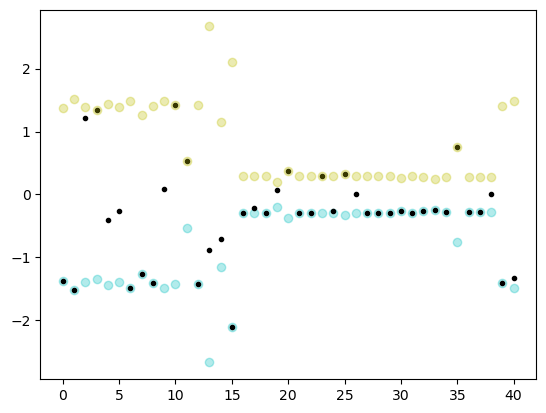

In [154]:
line_flow={}
import matplotlib.pyplot as plt
plt.figure()
s = 0

for l in model.nline:   
    b_in = ref.line[l].frombus-1
    b_out= ref.line[l].tobus-1
    
    line_flow[l] = pye.value(
        sum(
                (ref.pi[b_in,b] - ref.pi[b_out,b])*
                (sum(model.p[g-1] for g in ref.bus[b].gens) + model.ω[b] - ref.bus[b].pd - ref.bus[b].gs )

                for b in model.nbus
            )
    )
    
    
    if np.abs( np.abs(line_flow[l]) - ref.line[l].rate) <=1e-4:
#         print(l)
        s +=1
        

    plt.scatter(x=l, y=-ref.line[l].rate, color='c',marker='o', alpha=0.3)
    plt.scatter(x=l, y=line_flow[l], color='k',marker='.')
    plt.scatter(x=l, y=ref.line[l].rate, color='y',marker='o', alpha=0.3)
    
print(f"Total {s} constraint are active")

In [123]:
# for b in model.nbus:
#     print(b, ref.bus[b].pd, ref.bus[b].gs)

var = model.p.extract_values()
for k in var:
    if (var[k] is not None) and (var[k]!=0):
        print(k,var[k])

In [124]:
var = model.ω.extract_values()
for k in var:
    if (var[k] is not None) and (var[k]!=0):
        print(k,var[k])

0 -30.152628782053466
1 24.80787125144614
2 40.35082379097951
3 -73.73446319233739
4 -6.609578522990053
5 8.094722365311165
6 25.125130429322002
7 -7.818146811174891
8 -21.74475524475523
9 7.9980128851681505
10 6.826923076923079
11 -15.646626833045294
12 14.999999999999996
13 1.1398545133158604
14 -0.9565707984436201
15 3.1058020371517885
16 -5.154251970966784
17 -0.7020885616179988
18 5.310204757673243
19 -2.353571550630321
20 -9.722038408144403
21 10.435117051710204
22 0.318179579511719
23 1.3643660246542837
24 -0.8894876024232793
25 0.4892860115868754
26 -1.7300735024461786
27 28.662994352431337
28 0.5506816353001883
29 0.4683120185433609


In [125]:
for con in model.component_objects(pye.Constraint,active=True):
    print(con)

power_balance
line_flow_upper
line_flow_lower


In [155]:
for c in model.line_flow_upper:
    print(model.line_flow_upper[c].name, model.dual[model.line_flow_upper[c]])

line_flow_upper[1] 0.0
line_flow_upper[2] 0.0
line_flow_upper[3] 0.0
line_flow_upper[4] 0.0
line_flow_upper[5] 0.0
line_flow_upper[6] 0.0
line_flow_upper[7] 0.0
line_flow_upper[8] 0.0
line_flow_upper[9] 0.0
line_flow_upper[10] 0.0
line_flow_upper[11] 0.0
line_flow_upper[12] 0.0
line_flow_upper[13] 0.0
line_flow_upper[14] 0.0
line_flow_upper[15] 0.0
line_flow_upper[16] 0.0
line_flow_upper[17] 0.0
line_flow_upper[18] 0.0
line_flow_upper[19] 0.0
line_flow_upper[20] 0.0
line_flow_upper[21] 0.0
line_flow_upper[22] 0.0
line_flow_upper[23] 0.0
line_flow_upper[24] 0.0
line_flow_upper[25] 0.0
line_flow_upper[26] 0.0
line_flow_upper[27] 0.0
line_flow_upper[28] 0.0
line_flow_upper[29] 0.0
line_flow_upper[30] 0.0
line_flow_upper[31] 0.0
line_flow_upper[32] 0.0
line_flow_upper[33] 0.0
line_flow_upper[34] 0.0
line_flow_upper[35] 0.0
line_flow_upper[36] 0.0
line_flow_upper[37] 0.0
line_flow_upper[38] 0.0
line_flow_upper[39] 0.0
line_flow_upper[40] 0.0
line_flow_upper[41] 0.0


In [156]:
for c in model.line_flow_lower:
    print(model.line_flow_lower[c].name, model.dual[model.line_flow_lower[c]])

line_flow_lower[1] -0.0
line_flow_lower[2] -0.0
line_flow_lower[3] 0.0
line_flow_lower[4] 0.0
line_flow_lower[5] 0.0
line_flow_lower[6] 0.0
line_flow_lower[7] -0.0
line_flow_lower[8] -0.0
line_flow_lower[9] -0.0
line_flow_lower[10] 0.0
line_flow_lower[11] 0.0
line_flow_lower[12] 0.0
line_flow_lower[13] -0.0
line_flow_lower[14] 0.0
line_flow_lower[15] 0.0
line_flow_lower[16] -0.0
line_flow_lower[17] -0.0
line_flow_lower[18] 0.0
line_flow_lower[19] -0.0
line_flow_lower[20] 0.0
line_flow_lower[21] 0.0
line_flow_lower[22] -0.0
line_flow_lower[23] -0.0
line_flow_lower[24] 0.0
line_flow_lower[25] 0.0
line_flow_lower[26] 0.0
line_flow_lower[27] 0.0
line_flow_lower[28] -0.0
line_flow_lower[29] -0.0
line_flow_lower[30] -0.0
line_flow_lower[31] -0.0
line_flow_lower[32] -0.0
line_flow_lower[33] -0.0
line_flow_lower[34] -0.0
line_flow_lower[35] -0.0
line_flow_lower[36] 0.0
line_flow_lower[37] -0.0
line_flow_lower[38] -0.0
line_flow_lower[39] 0.0
line_flow_lower[40] -0.0
line_flow_lower[41] 0.0


In [157]:
# for l in model.nline:
#     b_in = ref.line[l].frombus-1
#     b_out= ref.line[l].tobus-1
#     print(l, (ref.pi[b_in,b] - ref.pi[b_out,b]) )